# Natural Language Processing



This project will give you practical experience using Natural Language Processing techniques. This project is in three parts:
- in part 1) you will use a dataset in a CSV file
- in part 2) you will use the Wikipedia API to directly access content
on Wikipedia.
- in part 3) you will make your notebook interactive


## Part 1)



- The CSV file is available at https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv
- The file contains a list of famous people and a brief overview.
- The goal of part 1) is to ...
  1. Pick one person from the list ( the reference person ) and output 10 other people who's overview are "closest" to the reference person in a Natural Language Processing sense
  1. Also output the sentiment of the overview of the reference person



In [56]:
import pandas as pd
import numpy as np
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [57]:
# Load data directly from S3

url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv"
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv'

In [58]:
# Inspect structure

df = pd.read_csv(url)
df

,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...
...,...,...,...
42781,<http://dbpedia.org/resource/Motoaki_Takenouchi>,Motoaki Takenouchi,motoaki takenouchi born july 8 1967 saitama pr...
42782,<http://dbpedia.org/resource/Alan_Judge_(footb...,"Alan Judge (footballer, born 1960)",alan graham judge born 14 may 1960 is a retire...
42783,<http://dbpedia.org/resource/Eduardo_Lara>,Eduardo Lara,eduardo lara lozano born 4 september 1959 in c...
42784,<http://dbpedia.org/resource/Tatiana_Faberg%C3...,Tatiana Faberg%C3%A9,tatiana faberg is an author and faberg scholar...


In [59]:
df.shape

(42786, 3)

In [60]:
df.head()

,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...


### Data Cleaning & Preprocessing

In [61]:
# Drop any missing values or duplicates

df = df.dropna(subset=['name', 'text']).drop_duplicates(subset=['URI']).reset_index(drop=True)

In [62]:
df

,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...
...,...,...,...
42781,<http://dbpedia.org/resource/Motoaki_Takenouchi>,Motoaki Takenouchi,motoaki takenouchi born july 8 1967 saitama pr...
42782,<http://dbpedia.org/resource/Alan_Judge_(footb...,"Alan Judge (footballer, born 1960)",alan graham judge born 14 may 1960 is a retire...
42783,<http://dbpedia.org/resource/Eduardo_Lara>,Eduardo Lara,eduardo lara lozano born 4 september 1959 in c...
42784,<http://dbpedia.org/resource/Tatiana_Faberg%C3...,Tatiana Faberg%C3%A9,tatiana faberg is an author and faberg scholar...


In [63]:
# Standardize text column

df['cleaned_text'] = df['text'].astype(str).str.lower().str.replace(r'[^a-z0-9\s]', '', regex=True)

In [64]:
df['cleaned_text']

,cleaned_text
0,digby morrell born 10 october 1979 is a former...
1,alfred j lewy aka sandy lewy graduated from un...
2,harpdog brown is a singer and harmonica player...
3,franz rottensteiner born in waidmannsfeld lowe...
4,henry krvits born 30 december 1974 in tallinn ...
...,...
42781,motoaki takenouchi born july 8 1967 saitama pr...
42782,alan graham judge born 14 may 1960 is a retire...
42783,eduardo lara lozano born 4 september 1959 in c...
42784,tatiana faberg is an author and faberg scholar...


#### Vectorization & Nearest Neighbors Search - Cosine Similarity (10000 Features)

In [65]:
# Initialize and fit TF-IDF Vectorizer across the full dataset

tfidf = TfidfVectorizer(stop_words='english', max_features=10000)
tfidf_matrix = tfidf.fit_transform(df['cleaned_text'])

In [66]:
# Pick a reference person (e.g., 'Motoaki Takenouchi')

ref_name = "Motoaki Takenouchi"
ref_idx = df[df['name'] == ref_name].index[0]

In [67]:
# Compute cosine similarity between reference vector and all vectors
cosine_sims = cosine_similarity(tfidf_matrix[ref_idx], tfidf_matrix).flatten()

In [68]:
# Get top 10 closest individuals (excluding the reference person itself)
similar_indices = cosine_sims.argsort()[::-1]
top_10_indices = [i for i in similar_indices if i != ref_idx][:10]


In [69]:
# Build Part 1 summary results DataFrame
part1_results = df.iloc[top_10_indices][['name', 'text']].copy()
part1_results['part1_similarity'] = cosine_sims[top_10_indices]
part1_results['part1_rank'] = range(1, 11)


In [70]:
print(f"Top 10 closest people to '{ref_name}' (Part 1):")

# Format and display part1_results directly as a DataFrame
display(part1_results[['part1_rank', 'name', 'part1_similarity']].reset_index(drop=True))

Top 10 closest people to 'Motoaki Takenouchi' (Part 1):


,part1_rank,name,part1_similarity
0,1,Jeremy Soule,0.359760
1,2,Hitoshi Sakimoto,0.314106
2,3,Kenji Ito,0.293880
3,4,Garry Schyman,0.289216
4,5,Earnest Woodall,0.286315
5,6,Yoko Shimomura,0.282700
6,7,Daniel Rosenfeld,0.274748
7,8,Manami Matsumae,0.265837
8,9,Wataru Hokoyama,0.262273
9,10,Comrade Artemio,0.259300


#### Vectorization & Nearest Neighbors Search - Cosine Similarity (No Max Features)

In [71]:
# Initialize and fit TF-IDF Vectorizer across the full dataset

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['cleaned_text'])

In [72]:
# Pick a reference person (e.g., 'Motoaki Takenouchi')

ref_name = "Motoaki Takenouchi"
ref_idx = df[df['name'] == ref_name].index[0]

In [73]:
# Compute cosine similarity between reference vector and all vectors
cosine_sims = cosine_similarity(tfidf_matrix[ref_idx], tfidf_matrix).flatten()

In [74]:
# Get top 10 closest individuals (excluding the reference person itself)
similar_indices = cosine_sims.argsort()[::-1]
top_10_indices = [i for i in similar_indices if i != ref_idx][:10]


In [75]:
# Build Part 1 summary results DataFrame
part1_results = df.iloc[top_10_indices][['name', 'text']].copy()
part1_results['part1_similarity'] = cosine_sims[top_10_indices]
part1_results['part1_rank'] = range(1, 11)


In [76]:
print(f"Top 10 closest people to '{ref_name}' (Part 1):")

# Format and display part1_results directly as a DataFrame
display(part1_results[['part1_rank', 'name', 'part1_similarity']].reset_index(drop=True))

Top 10 closest people to 'Motoaki Takenouchi' (Part 1):


,part1_rank,name,part1_similarity
0,1,Jeremy Soule,0.190587
1,2,Hitoshi Sakimoto,0.190247
2,3,Garry Schyman,0.178427
3,4,Kenji Ito,0.172877
4,5,Yoko Shimomura,0.153486
5,6,Keith Emerson,0.144923
6,7,Jack Wall (composer),0.144336
7,8,Earnest Woodall,0.138108
8,9,Nobuo Uematsu,0.137982
9,10,Richard Fraser (lyricist),0.137659


#### Comparing Ranking Based on Max Features

In [77]:
# Re-run 10k features vectorization to grab top 10

tfidf_10k = TfidfVectorizer(stop_words='english', max_features=10000)
tfidf_mat_10k = tfidf_10k.fit_transform(df['cleaned_text'])
sims_10k = cosine_similarity(tfidf_mat_10k[ref_idx], tfidf_mat_10k).flatten()
top10_10k_idx = [i for i in sims_10k.argsort()[::-1] if i != ref_idx][:10]

df_10k = df.iloc[top10_10k_idx][['name']].copy()
df_10k['Similarity (10k)'] = sims_10k[top10_10k_idx]
df_10k = df_10k.rename(columns={'name': 'Name (10k Features)'}).reset_index(drop=True)

# Re-run unlimited features vectorization to grab top 10

tfidf_all = TfidfVectorizer(stop_words='english')
tfidf_mat_all = tfidf_all.fit_transform(df['cleaned_text'])
sims_all = cosine_similarity(tfidf_mat_all[ref_idx], tfidf_mat_all).flatten()
top10_all_idx = [i for i in sims_all.argsort()[::-1] if i != ref_idx][:10]

df_all = df.iloc[top10_all_idx][['name']].copy()
df_all['Similarity (All)'] = sims_all[top10_all_idx]
df_all = df_all.rename(columns={'name': 'Name (All Features)'}).reset_index(drop=True)

# Combine side-by-side with Rank column and display as DataFrame

comparison_df = pd.DataFrame({'Rank': range(1, 11)})
comparison_df = pd.concat([comparison_df, df_10k, df_all], axis=1)

# Display results in formatted DataFrame
display(comparison_df)

,Rank,Name (10k Features),Similarity (10k),Name (All Features),Similarity (All)
0,1,Jeremy Soule,0.359760,Jeremy Soule,0.190587
1,2,Hitoshi Sakimoto,0.314106,Hitoshi Sakimoto,0.190247
2,3,Kenji Ito,0.293880,Garry Schyman,0.178427
3,4,Garry Schyman,0.289216,Kenji Ito,0.172877
4,5,Earnest Woodall,0.286315,Yoko Shimomura,0.153486
5,6,Yoko Shimomura,0.282700,Keith Emerson,0.144923
6,7,Daniel Rosenfeld,0.274748,Jack Wall (composer),0.144336
7,8,Manami Matsumae,0.265837,Earnest Woodall,0.138108
8,9,Wataru Hokoyama,0.262273,Nobuo Uematsu,0.137982
9,10,Comrade Artemio,0.259300,Richard Fraser (lyricist),0.137659


#### Implement KNN Nearest Neighbors Search

In [78]:
from sklearn.neighbors import NearestNeighbors

# Initialize and fit NearestNeighbors on the TF-IDF matrix (10k features)
# n_neighbors=11 to account for the reference person itself + 10 neighbors

knn = NearestNeighbors(n_neighbors=11, metric='cosine')
knn.fit(tfidf_mat_10k)

# Find nearest neighbors for the reference person

distances, indices = knn.kneighbors(tfidf_mat_10k[ref_idx])

# Flatten arrays and filter out the reference person itself

distances = distances.flatten()
indices = indices.flatten()

knn_top10_idx = [i for i in indices if i != ref_idx][:10]

# Create DataFrame for KNN results

df_knn = df.iloc[knn_top10_idx][['name']].copy()

# Convert cosine distance to cosine similarity (Similarity = 1 - Distance)

df_knn['Similarity (KNN)'] = 1 - distances[1:11]
df_knn = df_knn.rename(columns={'name': 'Name (KNN)'}).reset_index(drop=True)

# Display KNN results
display(df_knn)

,Name (KNN),Similarity (KNN)
0,Jeremy Soule,0.359760
1,Hitoshi Sakimoto,0.314106
2,Kenji Ito,0.293880
3,Garry Schyman,0.289216
4,Earnest Woodall,0.286315
5,Yoko Shimomura,0.282700
6,Daniel Rosenfeld,0.274748
7,Manami Matsumae,0.265837
8,Wataru Hokoyama,0.262273
9,Comrade Artemio,0.259300


#### Compare KNN vs. Cosine Similarity Side-by-Side

In [79]:
# Build Side-by-Side DataFrame Comparison

comparison_knn_cosine = pd.DataFrame({'Rank': range(1, 11)})
comparison_knn_cosine = pd.concat([
    comparison_knn_cosine,
    df_10k[['Name (10k Features)', 'Similarity (10k)']],
    df_knn[['Name (KNN)', 'Similarity (KNN)']]
], axis=1)

print("=== SIDE-BY-SIDE RANKING COMPARISON ===")
display(comparison_knn_cosine)

# Extract Names for Overlap and Rank Analysis

cosine_names = df_10k['Name (10k Features)'].tolist()
knn_names = df_knn['Name (KNN)'].tolist()

# Calculate Key Insights & Metrics

shared_names = set(cosine_names).intersection(set(knn_names))
exact_rank_matches = [name for i, name in enumerate(cosine_names) if knn_names[i] == name]

# Display Key Insights in a Clean DataFrame

insights_df = pd.DataFrame({
    'Metric': [
        'Total Shared Candidates in Top 10',
        'Exact Rank Position Matches',
        'Identical Ranks Match'
    ],
    'Value': [
        f"{len(shared_names)} / 10",
        f"{len(exact_rank_matches)} / 10",
        "100% Match (Exact same order)" if len(exact_rank_matches) == 10 else ", ".join(exact_rank_matches)
    ]
})

print("\n=== KEY COMPARISON INSIGHTS ===")
display(insights_df)

=== SIDE-BY-SIDE RANKING COMPARISON ===


,Rank,Name (10k Features),Similarity (10k),Name (KNN),Similarity (KNN)
0,1,Jeremy Soule,0.359760,Jeremy Soule,0.359760
1,2,Hitoshi Sakimoto,0.314106,Hitoshi Sakimoto,0.314106
2,3,Kenji Ito,0.293880,Kenji Ito,0.293880
3,4,Garry Schyman,0.289216,Garry Schyman,0.289216
4,5,Earnest Woodall,0.286315,Earnest Woodall,0.286315
5,6,Yoko Shimomura,0.282700,Yoko Shimomura,0.282700
6,7,Daniel Rosenfeld,0.274748,Daniel Rosenfeld,0.274748
7,8,Manami Matsumae,0.265837,Manami Matsumae,0.265837
8,9,Wataru Hokoyama,0.262273,Wataru Hokoyama,0.262273
9,10,Comrade Artemio,0.259300,Comrade Artemio,0.259300



=== KEY COMPARISON INSIGHTS ===


,Metric,Value
0,Total Shared Candidates in Top 10,10 / 10
1,Exact Rank Position Matches,10 / 10
2,Identical Ranks Match,100% Match (Exact same order)


### Sentiment Analysis on Overview Text

In [80]:
# Calculate sentiment polarity and subjectivity of the reference person’s overview text.

ref_overview = df.loc[ref_idx, 'text']
blob_part1 = TextBlob(ref_overview)

print(f"--- Sentiment Output for {ref_name} (Overview Text) ---\n")
print("Polarity (-1 to 1):", blob_part1.sentiment.polarity)
print("Subjectivity (0 to 1):", blob_part1.sentiment.subjectivity)

--- Sentiment Output for Motoaki Takenouchi (Overview Text) ---

Polarity (-1 to 1): 0.057575757575757565
Subjectivity (0 to 1): 0.3984848484848485


## Part 2)



- For the same reference person that you chose in Part 1), use the Wikipedia API to access the whole content of the reference person's Wikipedia page.
- The goal of Part 2) is to ...
  1. Print out the text of the Wikipedia article for the reference person
  1. Determine the sentiment of the text of the Wikipedia page for the reference person
  1. Collect the text of the Wikipedia pages from the 10 nearest neighbors from Part 1)
  1. Determine the nearness ranking of these 10 people to your reference person based on their entire Wikipedia page
  1. Compare, i.e. plot,  the nearest ranking from Step 1) with the Wikipedia page nearness ranking.  A difference of the rank is one means of comparison.



### Wikipedia API Integration & Comparison

In [81]:
# Install wikipedia-api

!pip install wikipedia-api

import wikipediaapi


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.2/129.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 12.6 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.4.2
    Uninstalling click-8.4.2:
      Successfully uninstalled click-8.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
huggingface-hub 1.23.0 requires click<9.0.0,>=8.4.2, but you have click 8.4.1 which is incompatible.


In [82]:
# Initialize Wikipedia API with a user agent

wiki = wikipediaapi.Wikipedia(user_agent="DataScienceProject/1.0", language="en")
wiki

In [83]:
# Function to safely fetch page text

def get_wiki_text(person_name):
    page = wiki.page(person_name)
    if page.exists():
        return page.text
    return ""

In [84]:
# Fetch full text for reference person

ref_wiki_text = get_wiki_text(ref_name)

# Fetch full text for the top 10 neighbors

part1_results['wiki_text'] = part1_results['name'].apply(get_wiki_text)

### Print Text & Sentiment of Wikipedia Article

In [85]:
# Print full text (or first 1,000 characters for preview)

print(f"--- Full Wikipedia Text for {ref_name} ---")
print(ref_wiki_text[:1000] + "\n...")

--- Full Wikipedia Text for Motoaki Takenouchi ---
Motoaki Takenouchi (武内 基朗, Takenouchi Motoaki; born July 8, 1967) is a Japanese composer, most recognized for his video game soundtracks during the 1990s, particularly for the Shining series of games. He has worked for companies such as Sega, Enix, Climax Entertainment, and Game Arts. Takenouchi studied music at the Tokyo University of the Arts, where he and fellow composer Hayato Matsuo were classmates. Around this time, he was involved with several projects, including arrangement under the supervision of Koichi Sugiyama.
Takenouchi's compositional approach often encompasses elements of progressive rock, jazz fusion, and symphonic, frequently making use of odd time signatures, virtuosic musical lines, syncopation and dissonance. He cited King Crimson, Yes, Frank Zappa, and Emerson, Lake & Palmer as some of his influences. In addition to his work on video game soundtracks, Takenouchi also composed music for some of the early releases o

In [86]:
# Determine sentiment of full Wikipedia article

blob_part2 = TextBlob(ref_wiki_text)
print("\n--- Sentiment Output (Full Wikipedia Article) ---\n")
print("Polarity:", blob_part2.sentiment.polarity)
print("Subjectivity:", blob_part2.sentiment.subjectivity)


--- Sentiment Output (Full Wikipedia Article) ---

Polarity: -0.03571428571428572
Subjectivity: 0.24880952380952379


### Re-Ranking Nearest Neighbors Using Entire Wikipedia Pages

In [101]:
# Combine reference person and 10 neighbors full wiki texts into a list

wiki_corpus = [ref_wiki_text] + part1_results['wiki_text'].tolist()

# Build a summary DataFrame for display

corpus_summary = pd.DataFrame({
    'Role': ['Reference Person'] + [f'Neighbor #{i}' for i in range(1, 11)],
    'Name': [ref_name] + part1_results['name'].tolist(),
    'Word Count': [len(text.split()) for text in wiki_corpus],
    'Preview': [text[:100].strip().replace('\n', ' ') + '...' for text in wiki_corpus]
})

# Display a clean, organized table instead of raw text

display(corpus_summary)

,Role,Name,Word Count,Preview
0,Reference Person,Motoaki Takenouchi,185,"Motoaki Takenouchi (武内 基朗, Takenouchi Motoaki;..."
1,Neighbor #1,Jeremy Soule,2594,Jeremy Soule ( SOHL) is an American composer o...
2,Neighbor #2,Hitoshi Sakimoto,1309,"Hitoshi Sakimoto (崎元 仁, Sakimoto Hitoshi; born..."
3,Neighbor #3,Garry Schyman,1193,"Garry Schyman is an American film, television,..."
4,Neighbor #4,Kenji Ito,1570,"Kenji Ito (伊藤 賢治, Itō Kenji; born July 5, 1968..."
5,Neighbor #5,Yoko Shimomura,1844,"Yoko Shimomura (Japanese: 下村 陽子, Hepburn: Shim..."
6,Neighbor #6,Keith Emerson,8375,Keith Noel Emerson (2 November 1944 – 11 March...
7,Neighbor #7,Jack Wall (composer),1129,Jack Wall is an American video game music comp...
8,Neighbor #8,Earnest Woodall,336,"Earnest Woodall (born July 24, 1959) is an Ame..."
9,Neighbor #9,Nobuo Uematsu,2240,"Nobuo Uematsu (植松 伸夫, Uematsu Nobuo; born Marc..."


In [88]:
# Vectorize using TF-IDF

wiki_tfidf = TfidfVectorizer(stop_words='english')
wiki_matrix = wiki_tfidf.fit_transform(wiki_corpus)

wiki_tfidf
wiki_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5853 stored elements and shape (11, 3563)>

In [89]:
# Compute similarity between reference page (index 0) and
# the 10 neighbors (indices 1 to 10)

wiki_sims = cosine_similarity(wiki_matrix[0:1], wiki_matrix[1:]).flatten()

In [90]:
# Add full Wikipedia similarity scores and calculate Part 2 rank

part1_results['part2_similarity'] = wiki_sims
part1_results['part2_rank'] = part1_results['part2_similarity'].rank(ascending=False, method='min').astype(int)

print(wiki_sims)
part1_results['part2_rank']


[0.09069175 0.11458574 0.10626519 0.11769503 0.09777824 0.09735098
 0.10862876 0.09026561 0.09254225 0.06539754]


,part2_rank
34893,8
5228,2
513,4
14977,1
10650,5
23459,6
10894,3
36707,9
76,7
18496,10


In [91]:
# Sort by Part 2 rank

part2_results = part1_results.sort_values(by='part2_rank').reset_index(drop=True)
print(part2_results[['part2_rank', 'name', 'part2_similarity', 'part1_rank']])

   part2_rank                       name  part2_similarity  part1_rank
0           1                  Kenji Ito          0.117695           4
1           2           Hitoshi Sakimoto          0.114586           2
2           3       Jack Wall (composer)          0.108629           7
3           4              Garry Schyman          0.106265           3
4           5             Yoko Shimomura          0.097778           5
5           6              Keith Emerson          0.097351           6
6           7              Nobuo Uematsu          0.092542           9
7           8               Jeremy Soule          0.090692           1
8           9            Earnest Woodall          0.090266           8
9          10  Richard Fraser (lyricist)          0.065398          10


### Comparative Analysis & Visualization

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

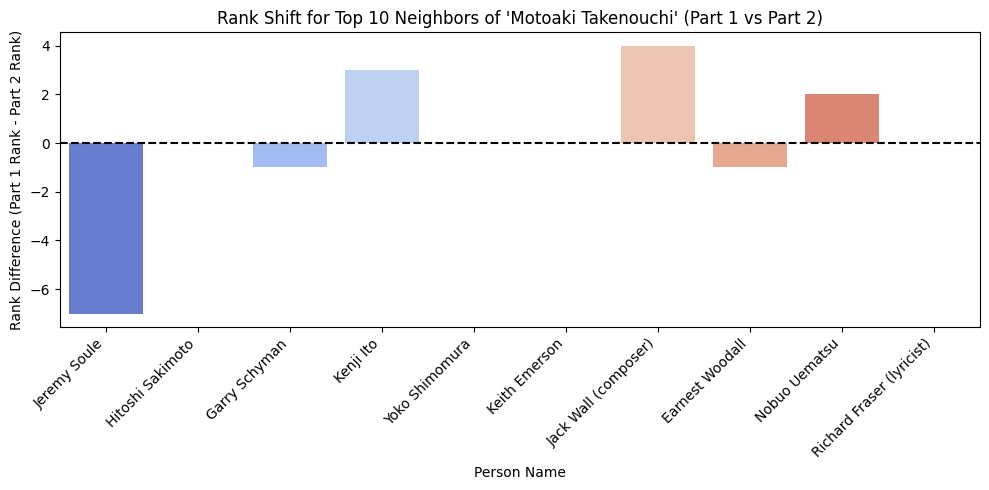

In [93]:
# Calculate rank difference
part1_results['rank_difference'] = part1_results['part1_rank'] - part1_results['part2_rank']

# Plot rank comparison

plt.figure(figsize=(10, 5))
sns.barplot(data=part1_results, x='name', y='rank_difference', palette='coolwarm', hue='name')

plt.xticks(rotation=45, ha='right')
plt.title(f"Rank Shift for Top 10 Neighbors of '{ref_name}' (Part 1 vs Part 2)")
plt.xlabel("Person Name")
plt.ylabel("Rank Difference (Part 1 Rank - Part 2 Rank)")
plt.axhline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

## Part 3)


Make an interactive notebook where a user can choose or enter a name and the notebook displays the 10 closest individuals.

In addition to presenting the project slides, at the end of the presentation each student will demonstrate their code using a famous person suggested by the other students that exists in the DBpedia set.


In [94]:
!curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv | wc -l

42786


In [95]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -1 |
tr , '\n' |
cat -n


     1	URI
     2	name
     3	text


In [96]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -2 |
tail -1 |
tr , '\n' |
cat -n


     1	<http://dbpedia.org/resource/Digby_Morrell>
     2	Digby Morrell
     3	digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league aflfrom western australia morrell played his early senior football for west perth his 44game senior career for the falcons spanned 19982000 and he was the clubs leading goalkicker in 2000 at the age of 21 morrell was recruited to the australian football league by the kangaroos football club with its third round selection in the 2001 afl rookie draft as a forward he twice kicked five goals during his time with the kangaroos the first was in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbaneafter the 2003 season morrell was traded along with david teague to the carlton football club in exchange for corey mckernan he played 32 games for the blues before being delisted at the end of 2005 he continued to play v

### Build Interactive UI Widget

In [97]:
import ipywidgets as widgets
from IPython.display import display, clear_output

In [98]:
# Create interactive widget so users can search any person in the DBpedia dataset

# Define the end-to-end lookup function

def find_closest_people(person_name):
    # Case-insensitive & whitespace-stripped lookup
    matched_rows = df[df['name'].str.strip().str.lower() == person_name.strip().lower()]

    if matched_rows.empty:
        print(f"\n'{person_name}' not found in dataset. Please try another name.")
        return

    # Locate index safely from the matched row

    idx = matched_rows.index[0]

    # Compute similarity across full TF-IDF matrix

    sims = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    top_indices = [i for i in sims.argsort()[::-1] if i != idx][:10]

    # Display results dataframe

    results = df.iloc[top_indices][['name']].copy()
    results['Cosine Similarity'] = sims[top_indices]

    # Compute overview sentiment

    text = df.loc[idx, 'text']
    sentiment = TextBlob(text).sentiment

    print(f"\n=== Results for: {df.loc[idx, 'name']} ===")
    print(f"Overview Sentiment: Polarity={sentiment.polarity:.3f}, Subjectivity={sentiment.subjectivity:.3f}")
    display(results.reset_index(drop=True))

In [99]:
# Create interactive widget so users can search any person in the DBpedia dataset

# Define the end-to-end lookup function

def find_closest_people(person_name):
    if person_name not in df['name'].values:
        print(f"\n'{person_name}' not found in dataset. Please try another name.")
        return

    # Locate index

    idx = df[df['name'] == person_name].index[0]

    # Compute similarity across full TF-IDF matrix

    sims = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    top_indices = [i for i in sims.argsort()[::-1] if i != idx][:10]

    # Display results dataframe

    results = df.iloc[top_indices][['name']].copy()
    results['Cosine Similarity'] = sims[top_indices]

    # Compute overview sentiment

    text = df.loc[idx, 'text']
    sentiment = TextBlob(text).sentiment

    print(f"\n'=== Results for: {person_name} ===")
    print(f"Overview Sentiment: Polarity={sentiment.polarity:.3f}, Subjectivity={sentiment.subjectivity:.3f}\n")
    display(results.reset_index(drop=True))


In [100]:
# Create Dropdown Widget with famous names from dataset

dropdown = widgets.Dropdown(
    options=sorted(df['name'].unique()[:100]), # Top 100 names for fast scrolling
    description='Select Person:',
    disabled=False,
    style={'description_width': 'initial'} #Ensures full label text displays
)

# Interactively display results

widgets.interact(find_closest_people, person_name=dropdown);

interactive(children=(Dropdown(description='Select Person:', options=('Aaron LaCrate', 'Adel Sellimi', 'Agnes …